## Window Warping
#### Definition:
 A random window of length w (typically ~10% of the series) is selected and either accelerated (downsampled by factor s<1) or decelerated (upsampled by factor s>1). The resulting series is then resampled back to the original length.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# import data

In [9]:
fd001=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD001_cleaned.csv',sep=',')
fd001_arr=fd001.to_numpy()
print(fd001_arr.shape)

(20631, 20)


In [10]:
fd002=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD002_cleaned.csv',sep=',')
fd002_arr=fd002.to_numpy()
print(fd002_arr.shape)


(53759, 20)


In [11]:
fd003=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD003_cleaned.csv',sep=',')
fd003_arr=fd003.to_numpy()
print(fd003_arr.shape)

(24720, 20)


In [12]:
fd004=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD004_cleaned.csv',sep=',')
fd004_arr=fd004.to_numpy()
print(fd004_arr.shape)

(61249, 20)


# visualisation of window warping

In [18]:
seq_len = fd001_arr.shape[0]
X=fd001_arr
window_size = int(np.sqrt(seq_len))
n_windows = seq_len // window_size
# Split into windows
windows = [X[i*window_size:(i+1)*window_size] for i in range(n_windows)]
# Shuffle windows
perm = np.random.permutation(n_windows)
shuffled = np.concatenate([windows[i] for i in perm], axis=0)
# Pad if needed (discard remainder for simplicity)
shuffled[:seq_len]

array([[ 69.    ,  98.    , 264.    , ..., 393.    ,  39.08  ,  23.3394],
       [ 69.    ,  99.    , 263.    , ..., 391.    ,  39.04  ,  23.4417],
       [ 69.    , 100.    , 262.    , ..., 393.    ,  38.93  ,  23.3111],
       ...,
       [ 91.    ,  65.    ,  70.    , ..., 394.    ,  38.83  ,  23.3457],
       [ 91.    ,  66.    ,  69.    , ..., 395.    ,  38.87  ,  23.1632],
       [ 91.    ,  67.    ,  68.    , ..., 393.    ,  38.8   ,  23.2551]])

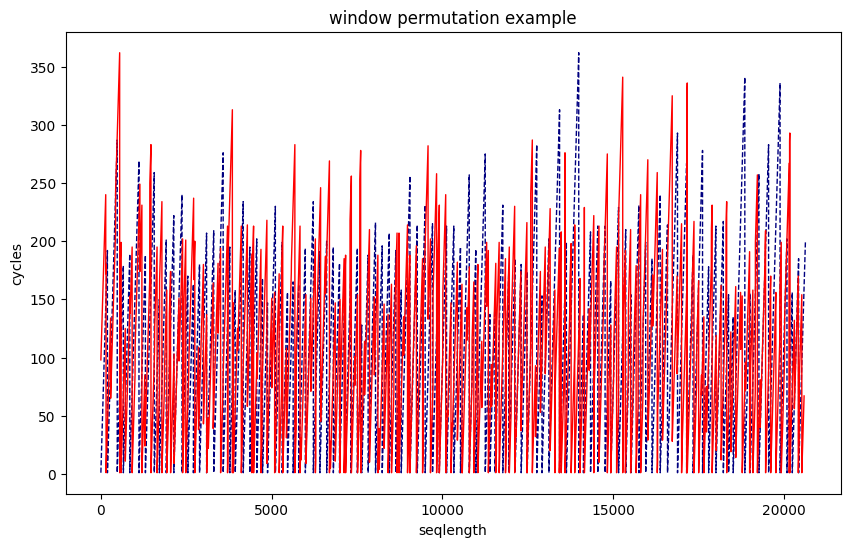

In [28]:
fig,ax= plt.subplots(figsize=(10,6))
ax.set_xlabel('seqlength')
ax.set_ylabel('cycles')
ax.set_title('window permutation example')
ax.plot(np.arange(seq_len),fd001_arr[:,1],label='cycles',linewidth=1,color='navy',linestyle='--')
ax.plot(np.arange(20592),shuffled[:,1],label='cycles after permutation',linewidth=1,color='red')


In [29]:
def window_permutation(X, window_size=None):
    """
    X : (seq_len, n_features)
    window_size : int, if None, set to sqrt(seq_len)
    returns permuted sequence
    """
    seq_len = X.shape[0]
    if window_size is None:
        window_size = int(np.sqrt(seq_len))
    n_windows = seq_len // window_size
    # Split into windows
    windows = [X[i*window_size:(i+1)*window_size] for i in range(n_windows)]
    # Shuffle windows
    perm = np.random.permutation(n_windows)
    shuffled = np.concatenate([windows[i] for i in perm], axis=0)
    # Pad if needed (discard remainder for simplicity)
    return shuffled[:seq_len]

In [30]:
fd001_cols=fd001.columns
fd002_cols=fd002.columns
fd003_cols=fd003.columns
fd004_cols=fd004.columns

In [31]:
scaled_fd001=window_permutation(fd001_arr)
print(scaled_fd001)
scaled_fd001_df=pd.DataFrame(scaled_fd001,columns=fd001_cols)
scaled_fd001_df.to_csv('window_permutation_fd001.csv')

[[ 81.      22.     218.     ... 393.      39.02    23.2729]
 [ 81.      23.     217.     ... 394.      38.92    23.3634]
 [ 81.      24.     216.     ... 392.      38.91    23.4123]
 ...
 [ 59.     185.      46.     ... 394.      38.84    23.2264]
 [ 59.     186.      45.     ... 394.      38.68    23.2328]
 [ 59.     187.      44.     ... 395.      38.72    23.3242]]


In [32]:
scaled_fd002=window_permutation(fd002_arr)
print(scaled_fd002)
scaled_fd002_df=pd.DataFrame(scaled_fd002,columns=fd002_cols)
scaled_fd002_df.to_csv('window_permutation_fd002.csv')

[[218.       5.     232.     ... 367.      24.51    14.656 ]
 [218.       6.     231.     ... 366.      24.63    14.6714]
 [218.       7.     230.     ... 334.      14.74     8.8516]
 ...
 [238.      29.     127.     ... 307.      14.39     8.6157]
 [238.      30.     126.     ... 331.      10.61     6.3569]
 [238.      31.     125.     ... 335.      14.86     8.9961]]


In [33]:
scaled_fd003=window_permutation(fd003_arr)
print(scaled_fd003)
scaled_fd003_df=pd.DataFrame(scaled_fd003,columns=fd003_cols)
scaled_fd003_df.to_csv('window_permutation_fd003.csv')

[[ 41.     168.     127.     ... 392.      39.25    23.4371]
 [ 41.     169.     126.     ... 393.      39.17    23.4178]
 [ 41.     170.     125.     ... 394.      38.97    23.4564]
 ...
 [ 51.     105.      85.     ... 392.      39.02    23.3445]
 [ 51.     106.      84.     ... 394.      38.94    23.3464]
 [ 51.     107.      83.     ... 392.      38.91    23.2448]]


In [34]:
scaled_fd004=window_permutation(fd004_arr)
print(scaled_fd004)
scaled_fd004_df=pd.DataFrame(scaled_fd004,columns=fd004_cols)
scaled_fd004_df.to_csv('window_permutation_fd004.csv')

[[ 75.     206.      24.     ... 331.      10.63     6.3535]
 [ 75.     207.      23.     ... 397.      38.59    23.1908]
 [ 75.     208.      22.     ... 336.      14.6      8.7961]
 ...
 [126.     282.      20.     ... 396.      39.45    23.7312]
 [126.     283.      19.     ... 366.      24.99    14.8732]
 [126.     284.      18.     ... 394.      39.45    23.7153]]
